Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey/HARey/cardbacks/tarot_round.png


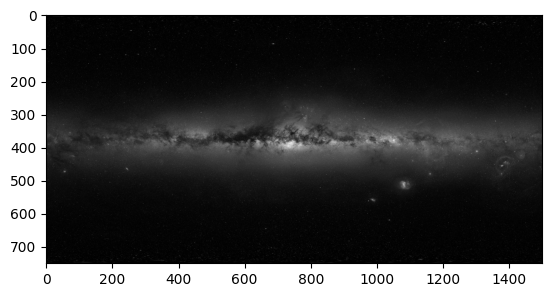

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HARey.harey_main import HAReyMain
from matplotlib.collections import LineCollection

harey = HAReyMain()



img = plt.imread('AllSkySurvey_Risinger1500.jpg')

gray = img.mean(axis=2, keepdims=False)

plt.imshow(gray, cmap='gray')

In [2]:
import numpy as np

# -----------------------------------------------------------
# 1. Galactic → Equatorial rotation matrix (J2000)
#    from standard IAU 1958 definitions
# -----------------------------------------------------------

# These are the *equatorial->galactic* rotation matrix values:
R_eq2gal = np.array([
    [-0.0548755604, -0.8734370902, -0.4838350155],
    [ 0.4941094279, -0.4448296300,  0.7469822445],
    [-0.8676661490, -0.1980763734,  0.4559837762]
])

# Galactic→equatorial is the transpose
R_gal2eq = R_eq2gal.T


# -----------------------------------------------------------
# 2. Bilinear sampler (NumPy only)
# -----------------------------------------------------------
def bilinear_sample(image, x, y):
    """
    image: H x W array
    x, y : floating pixel coordinates
    """
    H, W = image.shape

    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x1 = x0 + 1
    y1 = y0 + 1

    # clamp
    x0 = np.clip(x0, 0, W-1)
    x1 = np.clip(x1, 0, W-1)
    y0 = np.clip(y0, 0, H-1)
    y1 = np.clip(y1, 0, H-1)

    Ia = image[y0, x0]
    Ib = image[y0, x1]
    Ic = image[y1, x0]
    Id = image[y1, x1]

    wa = (x1 - x) * (y1 - y)
    wb = (x - x0) * (y1 - y)
    wc = (x1 - x) * (y - y0)
    wd = (x - x0) * (y - y0)

    return Ia*wa + Ib*wb + Ic*wc + Id*wd


# -----------------------------------------------------------
# 3. Main reprojection routine: Galactic image → RA/Dec image
# -----------------------------------------------------------

def reproject_galactic_to_equatorial(img_gal, out_w, out_h):
    """
    img_gal: input galactic full-sky equirectangular image (H_gal, W_gal, 3)
    out_w, out_h: output resolution in RA/Dec
    returns: new image (out_h, out_w, 3)
    """

    H_gal, W_gal = img_gal.shape

    # --- build target RA/Dec grid ---
    # RA: 0 → 360
    # Dec: +90 → –90
    ra = np.linspace(0, 2*np.pi, out_w, endpoint=False)        # radians
    dec = np.linspace(+np.pi/2, -np.pi/2, out_h)               # radians

    RA_grid, DEC_grid = np.meshgrid(ra, dec)

    # --- convert RA,Dec to Cartesian (equatorial) ---
    x = np.cos(DEC_grid) * np.cos(RA_grid)
    y = np.cos(DEC_grid) * np.sin(RA_grid)
    z = np.sin(DEC_grid)
    vec_eq = np.stack([x, y, z], axis=-1)

    # --- convert equatorial → galactic ---
    vec_gal = vec_eq @ R_eq2gal.T    # rotation

    xg = vec_gal[..., 0]
    yg = vec_gal[..., 1]
    zg = vec_gal[..., 2]

    # --- convert Cartesian → galactic lon/lat ---
    gal_lon = np.arctan2(yg, xg)     # radians
    gal_lat = np.arcsin(zg)

    # --- convert galactic lon/lat to pixel coords of source image ---
    # image x: ℓ 0..360  → 0..W_gal
    # image y: b +90→–90 → 0..H_gal
    x_src = (0.5 - gal_lon / (2*np.pi))%1 * (W_gal - 1)
    y_src = (0.5 - gal_lat/np.pi) * (H_gal - 1)

    # --- bilinear sample each RGB channel ---
    out = np.zeros((out_h, out_w, 3), dtype=img_gal.dtype)

    
    out = bilinear_sample(img_gal, x_src, y_src)

    return out


[]

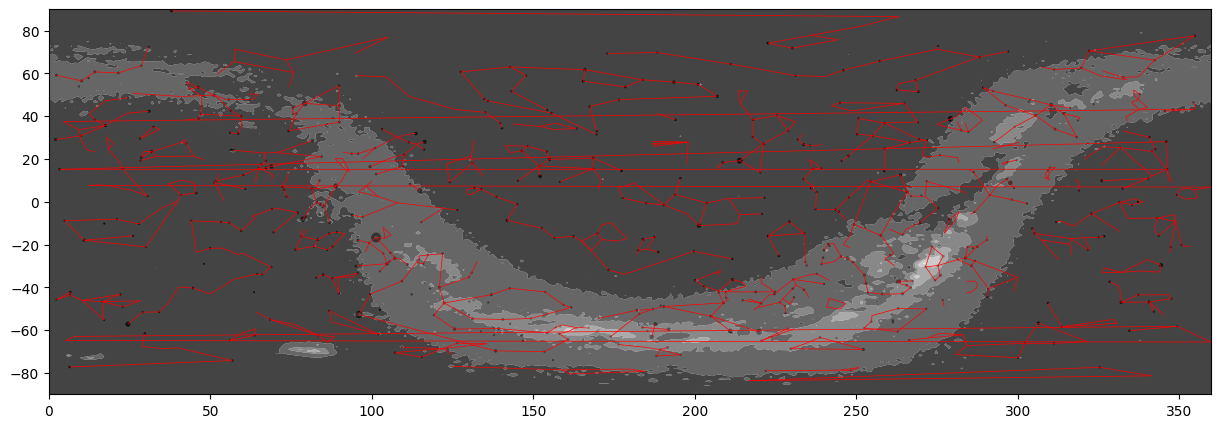

In [3]:
fig, ax = plt.subplots(figsize=(15,5))
ax.set_facecolor('white')
bright_stars = harey.stars[harey.stars.magnitude < 4]
ax.scatter(bright_stars.ra, bright_stars.dec, s=10*10**(-0.4*bright_stars.magnitude), color='k')

ra, dec = harey.stars.ra, harey.stars.dec

lines = []
for id in harey.con_ids:
    for line in [line for line in harey.cons[id]['lines']]:
        # Divide the line in individual segments
        for a,b in zip(line[1:], line[:-1]):
            lines.append([(ra[a], dec[a]), (ra[b], dec[b])])



high_lc = LineCollection(lines, colors='red', linewidths=0.5, alpha=1)
ax.add_collection(high_lc)
galaxy = reproject_galactic_to_equatorial(gray, 360, 180)
ax.contourf(galaxy, levels=5, cmap='grey', alpha=0.8, extent=(0,360,90,-90), antialiased=True)
plt.plot()


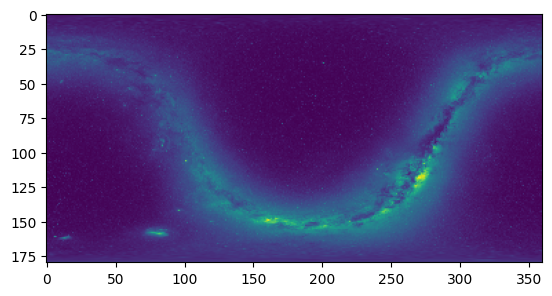

In [4]:
plt.imshow(galaxy)

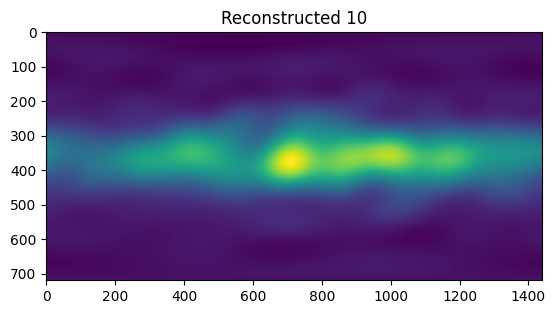

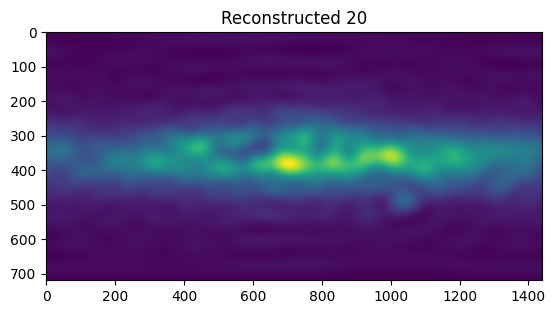

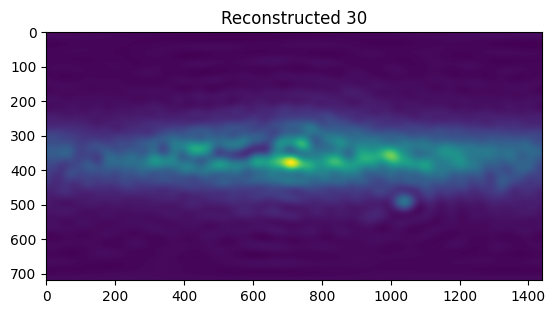

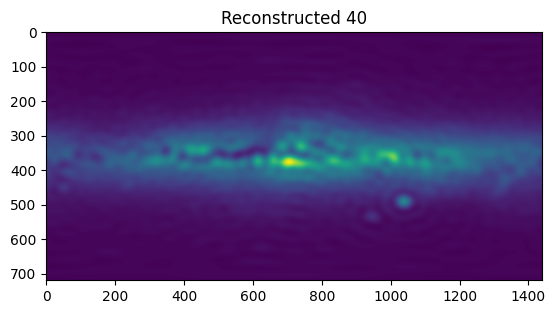

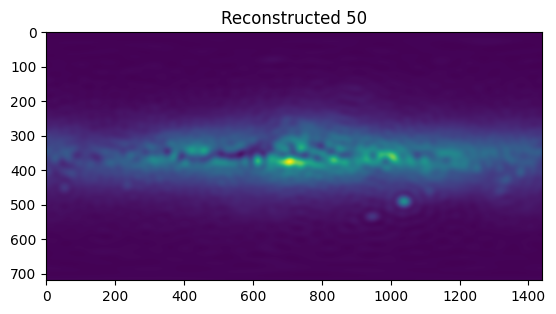

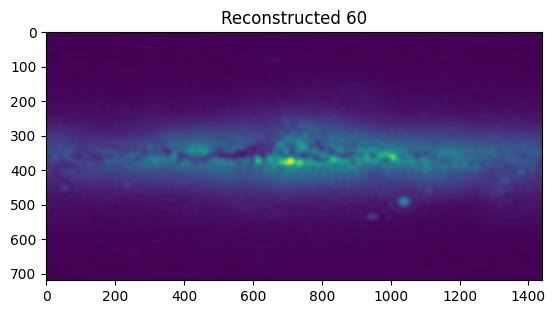

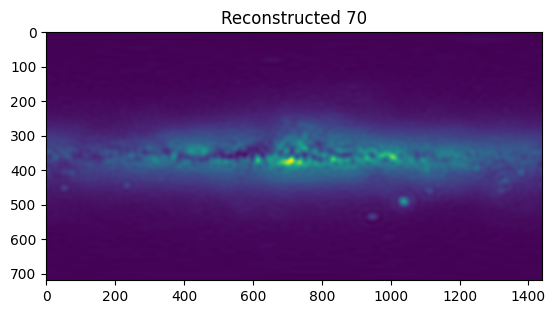

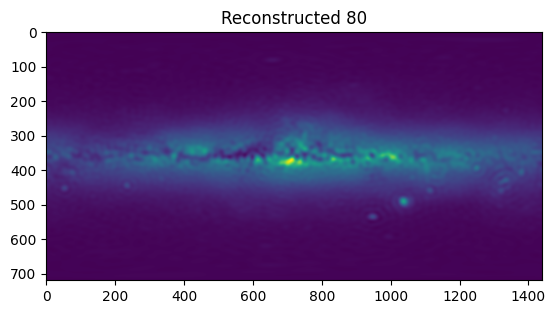

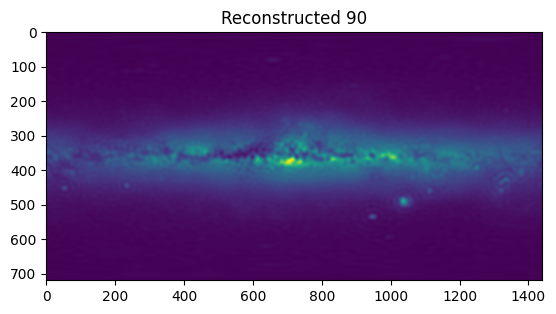

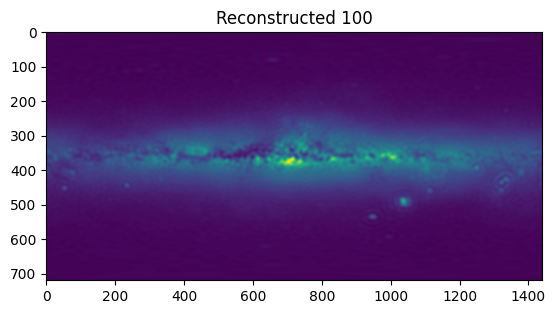

In [5]:
from scipy.special import sph_harm_y

C = np.load('milkyway_sph_harm_reconstruction_100.npy')
L_max = 100
l_max = 100

theta = np.linspace(0, np.pi, 720)
phi = np.linspace(0, 2*np.pi, 1440)

Theta, Phi = np.meshgrid(theta, phi)
L_list = [10,20, 30, 40, 50, 60, 70, 80, 90, 100]
reconstructed = np.zeros_like(Theta).ravel()

for l in range(l_max+1):
    for m in range(-l, l+1):
        reconstructed = reconstructed + (C[l, m + L_max]*sph_harm_y(l, m, Theta.ravel(), Phi.ravel())).real
        
    if l in L_list:
        out = reconstructed.reshape(Theta.shape)
        plt.title(f'Reconstructed {l}')
        plt.imshow(out.T)
        plt.show()

        np.save(f'milkyway_sph_harm_reconstruction_{l}.npy', out)
